In [1]:
#Bu notebookda 3. eğitilen yolov8m modelinin takip testi videosu olacaktır.
import os
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f.endswith('.pt') or f.endswith('.mp4') or f.endswith('.avi'):
            print(os.path.join(root, f))

/kaggle/input/datasets/zlemdemir/video-for-model-3/video_for_model_3.mp4
/kaggle/input/datasets/zlemdemir/tracking-with-model-3/3_model.pt


In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.8 MB/s eta 0:00:00a 0:00:01


In [3]:
reid_yaml = """tracker_type: botsort
track_high_thresh: 0.25
track_low_thresh: 0.1
new_track_thresh: 0.25
track_buffer: 60
match_thresh: 0.8
fuse_score: True

gmc_method: sparseOptFlow

proximity_thresh: 0.5
appearance_thresh: 0.8
with_reid: True
model: auto
"""

with open('/kaggle/working/botsort_reid.yaml', 'w') as f:
    f.write(reid_yaml)

print("botsort_reid.yaml oluşturuldu")

botsort_reid.yaml oluşturuldu


In [8]:
!ffmpeg -i /kaggle/input/datasets/zlemdemir/video-for-model-3/video_for_model_3.mp4 -t 100 -c copy /kaggle/working/videoo_kisa.mp4 -y
print("İlk 400 saniye kesildi")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [9]:
from ultralytics import YOLO
import pandas as pd

model_path = '/kaggle/input/datasets/zlemdemir/tracking-with-model-3/3_model.pt'
video_path = '/kaggle/working/videoo_kisa.mp4'

model = YOLO(model_path)

results = model.track(
    source=video_path,
    tracker='/kaggle/working/botsort_reid.yaml',
    save=True,
    conf=0.5,
    project='/kaggle/working',
    name='tracking_reid_v3'
)

# Koordinatları topla
koordinatlar = []
for frame_idx, result in enumerate(results):
    if result.boxes.id is not None:
        boxes = result.boxes.xywh.cpu().numpy()
        ids = result.boxes.id.cpu().numpy().astype(int)
        
        for box, track_id in zip(boxes, ids):
            x_center, y_center, w, h = box
            koordinatlar.append({
                'frame': frame_idx,
                'id': int(track_id),
                'x': float(x_center),
                'y': float(y_center),
                'width': float(w),
                'height': float(h)
            })

df = pd.DataFrame(koordinatlar)
df.to_csv('/kaggle/working/koordinatlar_v3.csv', index=False)

print(f"Toplam {len(df)} koordinat kaydedildi.")
print(f"Benzersiz ID sayısı: {df['id'].nunique()}")
print(f"Toplam frame: {df['frame'].max() + 1}")
print("\nHer ID'nin görünme sayısı:")
print(df.groupby('id').size().sort_values(ascending=False))


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/2501) /kaggle/working/videoo_kisa.mp4: 480x640 (no detections), 28.2ms
video 1/1 (frame 2/2501) /kaggle/working/videoo_kisa.mp4: 480x640 (no detections), 27.5ms
video 1/1 (frame 3/2501) /kaggle/working/videoo_kisa.mp4: 480x640 (no detections), 27.5ms
video 1/1 (frame 4/2501) /kaggle/working/videoo_kisa.mp4: 480x640 (no detections), 20.7ms
video 1/1 (frame 5/2501) /kaggle/working/videoo_kisa.mp4: 480x640 (no detections), 20.6ms
video 1/

In [10]:
import pandas as pd

# CSV'yi yükle
df = pd.read_csv('/kaggle/working/koordinatlar_v3.csv')

print(f"Öncesi: {df['id'].nunique()} farklı ID, {len(df)} koordinat")

# Tüm ID'leri 1'e ata
df['id'] = 1

# Kaydet
df.to_csv('/kaggle/working/koordinatlar_v3_birlesik.csv', index=False)

print(f"Sonrası: {df['id'].nunique()} ID, {len(df)} koordinat")
print("\nİlk 5 satır:")
print(df.head())

Öncesi: 5 farklı ID, 2191 koordinat
Sonrası: 1 ID, 2191 koordinat

İlk 5 satır:
   frame  id           x           y       width      height
0    113   1  629.597168  676.894409  207.272278   85.453918
1    114   1  634.999695  673.289917  205.319702   91.963684
2    115   1  642.518555  669.866943  197.134460   99.560913
3    116   1  649.633545  665.759949  197.228821  107.639404
4    117   1  655.075439  661.783020  199.070618  116.162476


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

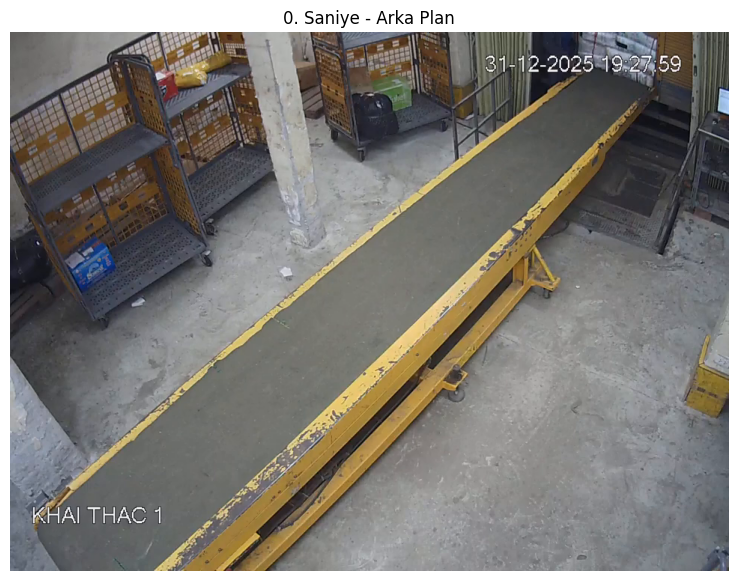

In [11]:
# ffmpeg ile 0. saniyedeki kareyi çıkar
!ffmpeg -ss 00:00:00 -i /kaggle/working/video_kisa.mp4 -frames:v 1 /kaggle/working/arkaplan.png -y

# Görüntüle
import cv2
import matplotlib.pyplot as plt

frame = cv2.imread('/kaggle/working/arkaplan.png')
print(f"Frame boyutu: {frame.shape}")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.title('0. Saniye - Arka Plan')
plt.axis('off')
plt.show()